# Circular phylogenetic tree with 3 metadata rings

This notebook generates a circular tree with three metadata rings:

1. **Domain** = inner ring
2. **Kingdom** = middle ring
3. **Phylum** = outer ring

It uses **Biopython** to read/root the Newick tree and **matplotlib** to draw the circular tree and metadata rings.

## Expected input files

Place these files in the same folder as this notebook, or adjust the paths in the CONFIG cell:

```text
inputs/all_rnammer_16S_mafft_fasta.treefile
inputs/metadata_with_kingdom.tsv
```

## Install packages if needed

```bash
pip install biopython pandas numpy matplotlib
```

In [1]:
# =============================================================================
# SECTION 1. Import libraries
# =============================================================================

import math
import re
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Patch

from Bio import Phylo

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [135]:
# =============================================================================
# SECTION 2. CONFIG: edit this cell for your files and figure style
# =============================================================================

# -------------------------------------------------------------------------
# Input / output paths
# -------------------------------------------------------------------------
TREE_FILE = Path('inputs/all_rnammer_16S_mafft_fasta.treefile')
METADATA_FILE = Path('inputs/metadata_with_kingdom.tsv')
OUT_DIR = Path('output_jupyter_circular_tree')

# -------------------------------------------------------------------------
# Rooting
# -------------------------------------------------------------------------
# Options:
#   'none'      = keep input Newick root/orientation
#   'midpoint'  = midpoint root
#   'outgroup'  = root using all tips whose metadata domain matches OUTGROUP_DOMAIN
ROOT_METHOD = 'outgroup'
OUTGROUP_DOMAIN = 'Archaea'

# -------------------------------------------------------------------------
# Figure size and layout
# -------------------------------------------------------------------------
FIG_SIZE = (18, 14)
DPI = 300

TREE_RADIUS = 1.00      # maximum radius for the tree tips
RING_GAP = 0.035        # gap between tree and first ring
RING_WIDTH = 0.055      # thickness of each metadata ring
RING_SPACING = 0.006    # gap between rings
LABEL_PAD = 0.03        # gap between outer ring and tip labels
PLOT_LIMIT = 1.60       # increase if labels are clipped

# -------------------------------------------------------------------------
# Tree drawing
# -------------------------------------------------------------------------
BRANCH_COLOR = '#222222'
BRANCH_WIDTH = 0.60

# -------------------------------------------------------------------------
# Tip labels
# -------------------------------------------------------------------------
SHOW_TIP_LABELS = True
TIP_LABEL_AS_ACCESSION = True
TIP_FONT_SIZE = 6.5
TIP_LABEL_MAXLEN = 40

# -------------------------------------------------------------------------
# Scale bar
# -------------------------------------------------------------------------
SHOW_SCALE_BAR = True
SCALE_BAR_LENGTH = 0.10     # in branch-length units
SCALE_BAR_XY = (-1.45, -1.45)
SCALE_BAR_LINEWIDTH = 1.4
SCALE_BAR_FONT_SIZE = 8

# -------------------------------------------------------------------------
# Manual colors
# -------------------------------------------------------------------------
DOMAIN_COLORS_MANUAL = {
    'Archaea': '#ff7f00',   # orange
    'Archea': '#ff7f00',    # included in case older typo appears
    'Bacteria': '#000000',  # black
    'bacteria': '#000000',
    'Unknown': '#cccccc',
}

KINGDOM_COLORS_MANUAL = {
    # Example:
    # 'Pseudomonadati': '#1f78b4',
}

PHYLUM_COLORS_MANUAL = {
    # Example:
    # 'Pseudomonadota': '#33a02c',
}

# -------------------------------------------------------------------------
# Automatic palettes
# -------------------------------------------------------------------------
KINGDOM_PALETTE = [
  '#a6cee3', '#1f78b4', '#ff7f00', '#FB5607',
  "#FFA600", "#17BECF", '#fdbf6f', "#3A86FF",
  '#cab2d6', '#6a3d9a', "#003F5C", '#e31a1c',
]

PHYLUM_PALETTE = ["#08306B", "#08519C", "#2171B5", "#4292C6", "#6BAED6", "#9ECAE1", "#C6DBEF", "#807DBA",
  "#2F4B7C", "#264653", "#005F73", "#74A9CF", "#A6BDDB", "#D0D1E6", "#00441B", "#006D2C",
  "#238B45", "#41AB5D", "#74C476", "#A1D99B", "#C7E9C0", "#7F7F7F", "#000000", "#06D6A0",
  "#66C2A4", "#99D8C9", "#CCECE6", "#3F007D", "#FFF3B0", "#54278F", "#6A51A3", "#EF476F",
  "#FFE66D", "#FFD166", "#9E9AC8", "#BCBDDC", "#DADAEB", "#FFCA3A", "#FFA600", "#FF9DA7",
  "#E377C2", "#9D4EDD", "#F4A261", "#D45087" , "#C77DFF", "#E0AAFF", "#253494", "#2C7FB8",
 "#B07AA1","#A05195" , "#FF7F0E", "#FB5607", "#2BB3A3", "#1D91C0", "#756BB1", "#17BECF"
]

MISSING_COLOR = '#cccccc'

# -------------------------------------------------------------------------
# Legend
# -------------------------------------------------------------------------
LEGEND_TITLE_SIZE = 10
LEGEND_TEXT_SIZE = 6.5
LEGEND_DOMAIN_POS = (0.78, 0.90)
LEGEND_KINGDOM_POS = (0.78, 0.85)
LEGEND_PHYLUM_POS = (0.78, 0.75)

# -------------------------------------------------------------------------
# Title
# -------------------------------------------------------------------------
SHOW_TITLE = True
TITLE_TEXT = '16S rRNA tree'

OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Output directory:', OUT_DIR.resolve())

Output directory: /Users/aria/Desktop/OSU_projects/Dr_Ussery/30K_type_strain_genomes/Aria_analysis/trees_rnammer16S_data/3_rnammer_based_results/tree_viz_bundles/16S_rnammer_circular_tree_bundle_claude_v3/output_jupyter_circular_tree


In [136]:
# =============================================================================
# SECTION 3. Helper functions
# =============================================================================

ACCESSION_RE = re.compile(r'(GC[AF]_\d+\.\d+)')

def extract_accession(tip_name):
    """Extract versioned GCA/GCF accession from a tree tip name."""
    if tip_name is None:
        return None
    match = ACCESSION_RE.search(str(tip_name))
    return match.group(1) if match else None


def clean_taxonomy_value(x):
    """Turn missing or empty taxonomy values into 'Unknown'."""
    if pd.isna(x):
        return 'Unknown'
    x = str(x).strip()
    if x == '' or x.lower() in {'nan', 'none'}:
        return 'Unknown'
    return x


def read_metadata(metadata_file):
    """Read metadata and ensure ID, domain, kingdom, and phylum columns exist."""
    meta = pd.read_csv(metadata_file, sep='\t', dtype=str)

    required = {'ID', 'domain', 'kingdom', 'phylum'}
    missing = required - set(meta.columns)
    if missing:
        raise ValueError(f'Metadata is missing required columns: {sorted(missing)}')

    for col in meta.columns:
        meta[col] = meta[col].map(clean_taxonomy_value)

    # Harmonize common spelling/case variants.
    meta['domain'] = meta['domain'].replace({
        'Archea': 'Archaea',
        'archaea': 'Archaea',
        'Bacteria': 'bacteria',
    })

    return meta


def build_color_map(values, palette, manual_colors=None):
    """Build category -> color dictionary."""
    manual_colors = manual_colors or {}
    categories = sorted(set(clean_taxonomy_value(v) for v in values))
    color_map = OrderedDict()

    auto_index = 0
    for category in categories:
        if category in manual_colors:
            color_map[category] = manual_colors[category]
        else:
            color_map[category] = palette[auto_index % len(palette)]
            auto_index += 1

    return color_map


def make_legend_handles(color_map):
    """Convert color map into matplotlib legend patches."""
    return [
        Patch(facecolor=color, edgecolor='none', label=str(category))
        for category, color in color_map.items()
    ]

print('Helper functions ready.')

Helper functions ready.


In [137]:
# =============================================================================
# SECTION 4. Rooting and metadata matching
# =============================================================================

def root_tree(tree, meta):
    """Root the tree according to ROOT_METHOD."""
    if ROOT_METHOD == 'none':
        print('[root] no rooting applied')
        return tree, 'unrooted/input-root'

    if ROOT_METHOD == 'midpoint':
        tree.root_at_midpoint()
        print('[root] midpoint rooting applied')
        return tree, 'midpoint-rooted'

    if ROOT_METHOD == 'outgroup':
        accession_to_domain = dict(zip(meta['ID'], meta['domain']))

        outgroup_tips = []
        for tip in tree.get_terminals():
            acc = extract_accession(tip.name)
            if acc is not None and accession_to_domain.get(acc) == OUTGROUP_DOMAIN:
                outgroup_tips.append(tip)

        print(f'[root] outgroup domain = {OUTGROUP_DOMAIN}')
        print(f'[root] outgroup tips found = {len(outgroup_tips)}')

        if len(outgroup_tips) == 0:
            print('[root] WARNING: no outgroup tips found; tree left unchanged')
            return tree, 'outgroup-not-found'

        tree.root_with_outgroup(*outgroup_tips)
        return tree, f'outgroup-rooted-{OUTGROUP_DOMAIN}'

    raise ValueError('ROOT_METHOD must be one of: none, midpoint, outgroup')


def merge_tips_with_metadata(tree, meta):
    """Create one table with one row per tree tip."""
    meta_first = meta.drop_duplicates('ID', keep='first').set_index('ID')

    rows = []
    for tip in tree.get_terminals():
        tip_name = str(tip.name)
        acc = extract_accession(tip_name)

        if acc in meta_first.index:
            m = meta_first.loc[acc].to_dict()
            status = 'matched'
        else:
            m = {'domain': 'Unknown', 'kingdom': 'Unknown', 'phylum': 'Unknown'}
            status = 'unmatched'

        rows.append({
            'tip': tip_name,
            'accession': acc if acc else '',
            'match_status': status,
            'domain': clean_taxonomy_value(m.get('domain', 'Unknown')),
            'kingdom': clean_taxonomy_value(m.get('kingdom', 'Unknown')),
            'phylum': clean_taxonomy_value(m.get('phylum', 'Unknown')),
        })

    return pd.DataFrame(rows)

print('Rooting and metadata-matching functions ready.')

Rooting and metadata-matching functions ready.


In [138]:
# =============================================================================
# SECTION 5. Circular layout
# =============================================================================

def compute_circular_coordinates(tree):
    """
    Assign each clade an angle and radius.

    Radius comes from branch length. Terminal tips are aligned to TREE_RADIUS
    so the metadata rings are clean and evenly placed.
    """
    terminals = tree.get_terminals()
    n_tips = len(terminals)

    angles = np.linspace(
        math.pi / 2,
        math.pi / 2 - 2 * math.pi,
        n_tips,
        endpoint=False,
    )

    coords = {}
    for tip, angle in zip(terminals, angles):
        coords[tip] = {'angle': float(angle), 'radius': 0.0}

    depths = tree.depths(unit_branch_lengths=False)

    for clade in tree.find_clades(order='postorder'):
        if clade.is_terminal():
            coords[clade]['radius'] = depths[clade]
        else:
            child_tips = clade.get_terminals()
            mean_angle = np.mean([coords[t]['angle'] for t in child_tips])
            coords[clade] = {
                'angle': float(mean_angle),
                'radius': depths[clade],
            }

    max_depth = max(v['radius'] for v in coords.values())
    if max_depth == 0:
        max_depth = 1.0

    for clade in coords:
        coords[clade]['radius'] = coords[clade]['radius'] / max_depth * TREE_RADIUS

    for tip in terminals:
        coords[tip]['radius'] = TREE_RADIUS

    return coords


def polar_to_xy(radius, angle):
    """Convert polar coordinates to x/y."""
    return radius * math.cos(angle), radius * math.sin(angle)

print('Circular layout functions ready.')

Circular layout functions ready.


In [139]:
# =============================================================================
# SECTION 6. Drawing functions
# =============================================================================

def draw_branch(ax, parent, child, coords):
    """Draw one circular-tree branch."""
    parent_angle = coords[parent]['angle']
    parent_radius = coords[parent]['radius']
    child_angle = coords[child]['angle']
    child_radius = coords[child]['radius']

    # Arc at parent radius.
    a0, a1 = sorted([parent_angle, child_angle])
    arc_angles = np.linspace(a0, a1, 30)
    ax.plot(
        parent_radius * np.cos(arc_angles),
        parent_radius * np.sin(arc_angles),
        color=BRANCH_COLOR,
        lw=BRANCH_WIDTH,
    )

    # Radial line from parent radius to child radius.
    x0, y0 = polar_to_xy(parent_radius, child_angle)
    x1, y1 = polar_to_xy(child_radius, child_angle)
    ax.plot([x0, x1], [y0, y1], color=BRANCH_COLOR, lw=BRANCH_WIDTH)


def draw_ring_segment(ax, angle, angle_width, inner_radius, outer_radius, color):
    """Draw one annular wedge segment for one metadata category."""
    theta1 = math.degrees(angle - angle_width / 2)
    theta2 = math.degrees(angle + angle_width / 2)

    ax.add_patch(
        Wedge(
            center=(0, 0),
            r=outer_radius,
            theta1=theta1,
            theta2=theta2,
            width=outer_radius - inner_radius,
            facecolor=color,
            edgecolor='none',
            linewidth=0,
        )
    )


def draw_tip_label(ax, angle, radius, label):
    """Draw a readable rotated tip label."""
    if not label:
        return

    if len(label) > TIP_LABEL_MAXLEN:
        label = label[:TIP_LABEL_MAXLEN - 1] + '…'

    degrees = math.degrees(angle)

    if -90 <= degrees <= 90:
        rotation = degrees
        ha = 'left'
    else:
        rotation = degrees + 180
        ha = 'right'

    x, y = polar_to_xy(radius, angle)
    ax.text(
        x,
        y,
        label,
        fontsize=TIP_FONT_SIZE,
        rotation=rotation,
        rotation_mode='anchor',
        ha=ha,
        va='center',
    )


def draw_scale_bar(ax, branch_scale):
    """Draw branch-length scale bar."""
    if not SHOW_SCALE_BAR:
        return

    x0, y0 = SCALE_BAR_XY
    bar_len = SCALE_BAR_LENGTH * branch_scale

    ax.plot([x0, x0 + bar_len], [y0, y0], color='black', lw=SCALE_BAR_LINEWIDTH)
    ax.plot([x0, x0], [y0 - 0.012, y0 + 0.012], color='black', lw=SCALE_BAR_LINEWIDTH)
    ax.plot([x0 + bar_len, x0 + bar_len], [y0 - 0.012, y0 + 0.012], color='black', lw=SCALE_BAR_LINEWIDTH)

    ax.text(
        x0 + bar_len / 2,
        y0 - 0.04,
        f'{SCALE_BAR_LENGTH} substitutions/site',
        ha='center',
        va='top',
        fontsize=SCALE_BAR_FONT_SIZE,
    )

print('Drawing functions ready.')

Drawing functions ready.


In [140]:
# =============================================================================
# SECTION 7. Main plotting function
# =============================================================================

def make_plot(tree, tip_df, output_prefix, root_note):
    """Draw and save the circular tree figure."""
    coords = compute_circular_coordinates(tree)
    terminals = tree.get_terminals()
    n_tips = len(terminals)

    raw_depths = tree.depths(unit_branch_lengths=False)
    max_depth = max(raw_depths.values()) if raw_depths else 1.0
    if max_depth == 0:
        max_depth = 1.0
    branch_scale = TREE_RADIUS / max_depth

    domain_cmap = build_color_map(
        tip_df['domain'],
        ['#ff7f00', '#000000'],
        DOMAIN_COLORS_MANUAL,
    )
    kingdom_cmap = build_color_map(tip_df['kingdom'], KINGDOM_PALETTE, KINGDOM_COLORS_MANUAL)
    phylum_cmap = build_color_map(tip_df['phylum'], PHYLUM_PALETTE, PHYLUM_COLORS_MANUAL)

    tip_lookup = tip_df.set_index('tip').to_dict('index')

    # Ring radii.
    ring1_inner = TREE_RADIUS + RING_GAP
    ring1_outer = ring1_inner + RING_WIDTH

    ring2_inner = ring1_outer + RING_SPACING
    ring2_outer = ring2_inner + RING_WIDTH

    ring3_inner = ring2_outer + RING_SPACING
    ring3_outer = ring3_inner + RING_WIDTH

    label_radius = ring3_outer + LABEL_PAD
    angle_width = 2 * math.pi / n_tips

    fig, ax = plt.subplots(figsize=FIG_SIZE)
    ax.set_aspect('equal')
    ax.set_xlim(-PLOT_LIMIT, PLOT_LIMIT)
    ax.set_ylim(-PLOT_LIMIT, PLOT_LIMIT)
    ax.axis('off')

    # Draw branches.
    for clade in tree.find_clades(order='preorder'):
        if clade.is_terminal():
            continue
        for child in clade.clades:
            draw_branch(ax, clade, child, coords)

    # Draw rings and tip labels.
    for tip in terminals:
        angle = coords[tip]['angle']
        row = tip_lookup.get(str(tip.name), {})

        domain = row.get('domain', 'Unknown')
        kingdom = row.get('kingdom', 'Unknown')
        phylum = row.get('phylum', 'Unknown')

        draw_ring_segment(ax, angle, angle_width, ring1_inner, ring1_outer, domain_cmap.get(domain, MISSING_COLOR))
        draw_ring_segment(ax, angle, angle_width, ring2_inner, ring2_outer, kingdom_cmap.get(kingdom, MISSING_COLOR))
        draw_ring_segment(ax, angle, angle_width, ring3_inner, ring3_outer, phylum_cmap.get(phylum, MISSING_COLOR))

        if SHOW_TIP_LABELS:
            label = row.get('accession', '') if TIP_LABEL_AS_ACCESSION else str(tip.name)
            draw_tip_label(ax, angle, label_radius, label)

    draw_scale_bar(ax, branch_scale)

    # Legends.
    fig.legend(
        handles=make_legend_handles(domain_cmap),
        title='Domain',
        loc='upper left',
        bbox_to_anchor=LEGEND_DOMAIN_POS,
        frameon=False,
        fontsize=LEGEND_TEXT_SIZE,
        title_fontsize=LEGEND_TITLE_SIZE,
    )

    fig.legend(
        handles=make_legend_handles(kingdom_cmap),
        title='Kingdom',
        loc='upper left',
        bbox_to_anchor=LEGEND_KINGDOM_POS,
        frameon=False,
        fontsize=LEGEND_TEXT_SIZE,
        title_fontsize=LEGEND_TITLE_SIZE,
    )

    fig.legend(
        handles=make_legend_handles(phylum_cmap),
        title='Phylum',
        loc='upper left',
        bbox_to_anchor=LEGEND_PHYLUM_POS,
        frameon=False,
        fontsize=LEGEND_TEXT_SIZE,
        title_fontsize=LEGEND_TITLE_SIZE,
        ncol=2,
    )

    if SHOW_TITLE:
        fig.suptitle(
            f'{TITLE_TEXT} — {root_note}',
            fontsize=13,
            weight='bold',
            y=0.96,
        )

    fig.subplots_adjust(left=0.02, right=0.74, top=0.94, bottom=0.04)

    png = output_prefix.with_suffix('.png')
    pdf = output_prefix.with_suffix('.pdf')
    fig.savefig(png, dpi=DPI, facecolor='white')
    fig.savefig(pdf, facecolor='white')
    plt.close(fig)

    print(f'[done] {png}')
    print(f'[done] {pdf}')

print('Main plotting function ready.')

Main plotting function ready.


In [141]:
# =============================================================================
# SECTION 8. Load input files
# =============================================================================

if not TREE_FILE.exists():
    raise FileNotFoundError(f'Tree file not found: {TREE_FILE}')

if not METADATA_FILE.exists():
    raise FileNotFoundError(f'Metadata file not found: {METADATA_FILE}')

meta = read_metadata(METADATA_FILE)
print(f'[metadata] rows = {len(meta)}')
display(meta.head())

tree = Phylo.read(TREE_FILE, 'newick')
print(f'[tree] tips = {len(tree.get_terminals())}')

# Replace missing branch lengths with 0.0 so layout and scale-bar code are stable.
for clade in tree.find_clades():
    if clade.branch_length is None:
        clade.branch_length = 0.0

print('Input files loaded successfully.')

[metadata] rows = 56


,ID,phylum,domain,Species_Name_Used_For_Search,kingdom
0,GCA_000008545.1,Thermotogota,bacteria,Thermotoga maritima,Thermotogati
1,GCA_000008565.1,Deinococcota,bacteria,Deinococcus radiodurans,Thermotogati
2,GCA_000009045.1,Bacillota,bacteria,Bacillus subtilis,Bacillati
3,GCA_000010305.1,Gemmatimonadota,bacteria,Gemmatimonas aurantiaca,Pseudomonadati
4,GCA_000011445.1,Mycoplasmatota,bacteria,Mycoplasma mycoides,Bacillati


[tree] tips = 110
Input files loaded successfully.


In [142]:
# =============================================================================
# SECTION 9. Root tree and merge metadata
# =============================================================================

tree, root_note = root_tree(tree, meta)

tip_df = merge_tips_with_metadata(tree, meta)
n_matched = (tip_df['match_status'] == 'matched').sum()
print(f'[match] matched tips = {n_matched} / {len(tip_df)}')

suffix = 'unrooted' if ROOT_METHOD == 'none' else ROOT_METHOD

merged_table = OUT_DIR / f'tip_metadata_merged_{suffix}.tsv'
tip_df.to_csv(merged_table, sep='\t', index=False)
print(f'[done] {merged_table}')

display(tip_df.head())

[root] outgroup domain = Archaea
[root] outgroup tips found = 8
[match] matched tips = 110 / 110
[done] output_jupyter_circular_tree/tip_metadata_merged_outgroup.tsv


,tip,accession,match_status,domain,kingdom,phylum
0,GCA_000008545.1_rRNA_AE000512.1_188975-190520_...,GCA_000008545.1,matched,bacteria,Thermotogati,Thermotogota
1,GCA_054656935.1_rRNA_BAAHXJ010000003.1_400340-...,GCA_054656935.1,matched,bacteria,Pseudomonadati,Aquificota
2,GCA_000734015.1_rRNA_CP008796.1_1299223-130078...,GCA_000734015.1,matched,bacteria,Pseudomonadati,Thermodesulfobacteriota
3,GCA_001547735.1_rRNA_AP013035.1_1426791-142836...,GCA_001547735.1,matched,bacteria,Pseudomonadati,Thermosulfidibacterota
4,GCA_000018865.1_rRNA_CP000909.1_1585298-158677...,GCA_000018865.1,matched,bacteria,Bacillati,Chloroflexota


In [143]:
# =============================================================================
# SECTION 10. Generate figure
# =============================================================================

output_prefix = OUT_DIR / f'circular_tree_{suffix}'
make_plot(tree, tip_df, output_prefix, root_note)

print('PNG:', output_prefix.with_suffix('.png'))
print('PDF:', output_prefix.with_suffix('.pdf'))

[done] output_jupyter_circular_tree/circular_tree_outgroup.png
[done] output_jupyter_circular_tree/circular_tree_outgroup.pdf
PNG: output_jupyter_circular_tree/circular_tree_outgroup.png
PDF: output_jupyter_circular_tree/circular_tree_outgroup.pdf


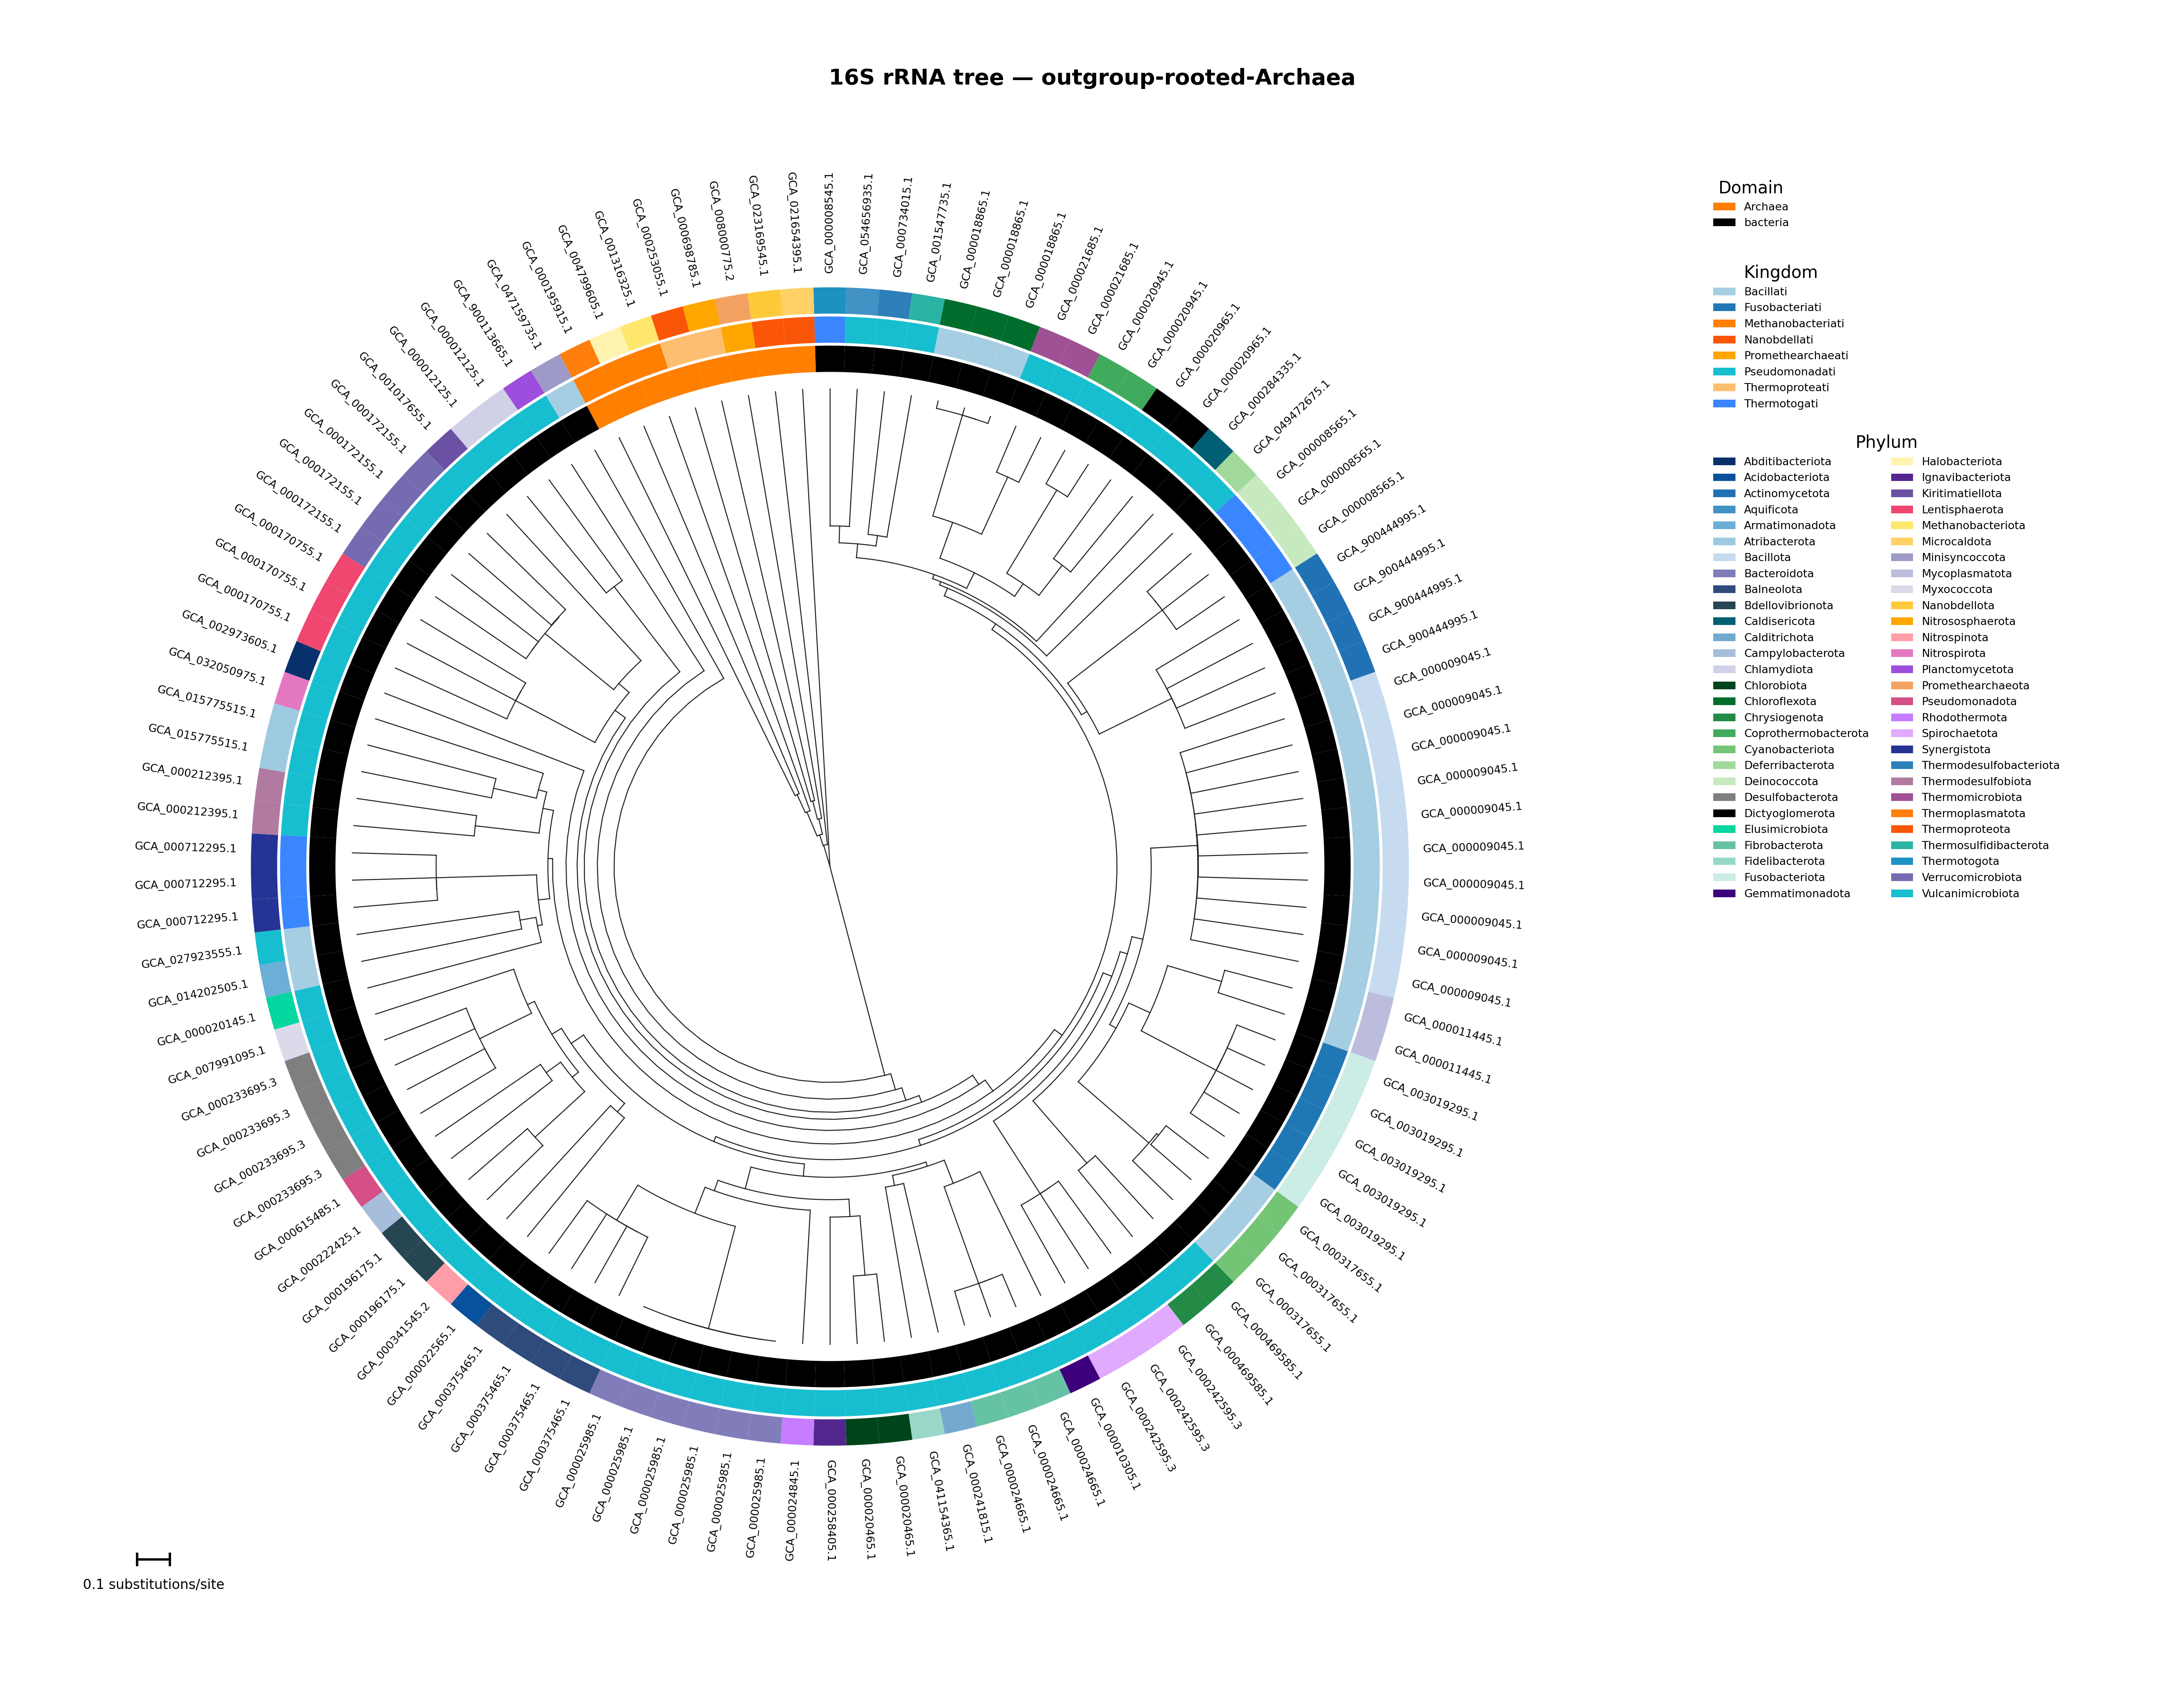

In [144]:
# =============================================================================
# SECTION 11. Display the generated PNG inside Jupyter
# =============================================================================

from IPython.display import Image, display

png_path = output_prefix.with_suffix('.png')
display(Image(filename=str(png_path)))

In [145]:
import numpy as np
x=np.array([10, 2, 33, 24])
mean= np.mean(x)
print(mean)
sd= np.std(x)
print(sd)
z=x[0]-mean/sd
print(z)

17.25
12.028611723719408
8.565919293414014
